In [1]:
import numpy as np
from importlib import reload
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import pandas as pd
%matplotlib widget

In [30]:
import prospector_emulator_libs.mcmc_libs as mcmc_libs
import prospector_emulator_libs.data_libs as data_libs
import prospector_emulator_libs.sps_libs as sps_libs
mcmc_libs = reload(mcmc_libs)
data_libs = reload(data_libs)
sps_libs = reload(sps_libs)

In [3]:
emulator_filename = "/Users/brianwang76/SPHEREx/pwang55/prospector_emulator/emulator_outputs/z0001_emulators/z0001_emulator.pt"

emcmc_obj = mcmc_libs.PCAEmulatorMCMC(
    # config_filename="configs/pca_template_mcmc_config.yaml",
    emulator=emulator_filename,
    vectorize=True
    # filters=None
)

In [4]:
zred = emcmc_obj.emulator.default_params['zred']
emcmc_obj.train_param_keys

['logmass',
 'logzsol',
 'logsfr_ratios0',
 'logsfr_ratios1',
 'logsfr_ratios2',
 'logsfr_ratios3',
 'logsfr_ratios4',
 'logsfr_ratios5',
 'dust2',
 'dust_index',
 'duste_qpah']

In [243]:
c = 3e18

template_dir = "/Users/brianwang76/SPHEREx/SPHEREx-L4-Redshift-Pipeline/redshifts/data/SED/GALAXY/EMPIRICAL_SPHEREX_V2.1_CONT"
# template_dir = "/Users/brianwang76/SPHEREx/SPHEREx-L4-Redshift-Pipeline/redshifts/data/SED/GALAXY/BROWN_COSMOS_CONT"

template_pathname = Path(template_dir) / "empr_temp35.dat"
# template_pathname = Path(template_dir) / "ARP_118_SPEC.dat"


template = np.genfromtxt(template_pathname)
template_lam_A = template[:,0]
template_lam_um = template_lam_A/1e4
template_res_flambda = template[:,1]
template_res_fnu = template_res_flambda * template_lam_A**2 / c

h = (template_lam_um>0.2) & (template_lam_um<5.5)
lbs = template_lam_um[h]
flux0 = template_res_fnu[h]
flux0 = flux0 / np.linalg.norm(flux0)

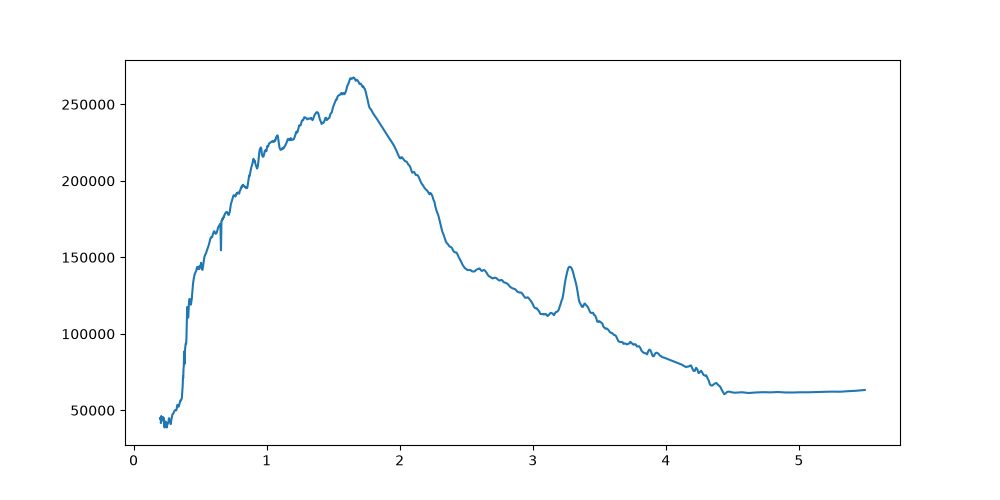

In [244]:
scale = 1e7

plt.close()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lbs, flux0*scale)

In [213]:
scale1 = 1e7
flux1 = flux0 * scale1

In [214]:
emcmc_obj.fixed_dicts

{'zred': 0.001,
 'dust_ratio': 1.0,
 'log10_duste_gamma': -2.0,
 'duste_umin': 1.0,
 'add_neb_emission': False,
 'add_neb_continuum': False,
 'gas_logz': 0.0,
 'gas_logu': -2.0,
 'add_agn': False,
 'log10_fagn': -4.0,
 'log10_agn_tau': 0.7,
 'nbins': 7}

In [215]:
emcmc_obj.run_mcmc(
    flux=flux1,
    flux_lbs=lbs,
    filters=False,
    nsteps=6000,
    # discard=2500,
    # thin=5,
    results=False
)

100%|██████████| 6000/6000 [01:43<00:00, 58.00it/s]


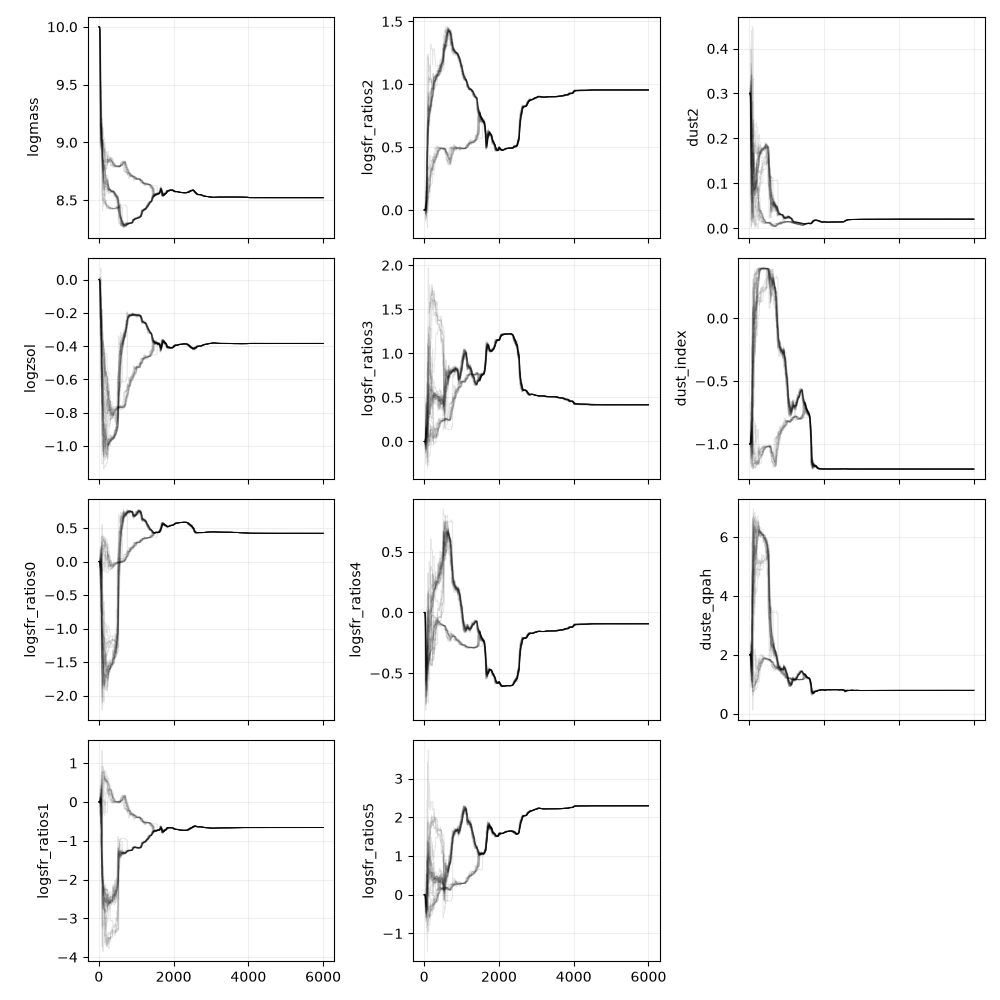

In [216]:
plt.close()
mcmc_libs.plot_chain(emcmc_obj.full_samples, ylabels=emcmc_obj.free_param_keys, figsize=(10, 10))

In [217]:
discard = 3000
thin = 2
results = emcmc_obj.get_results(discard=discard, thin=thin)

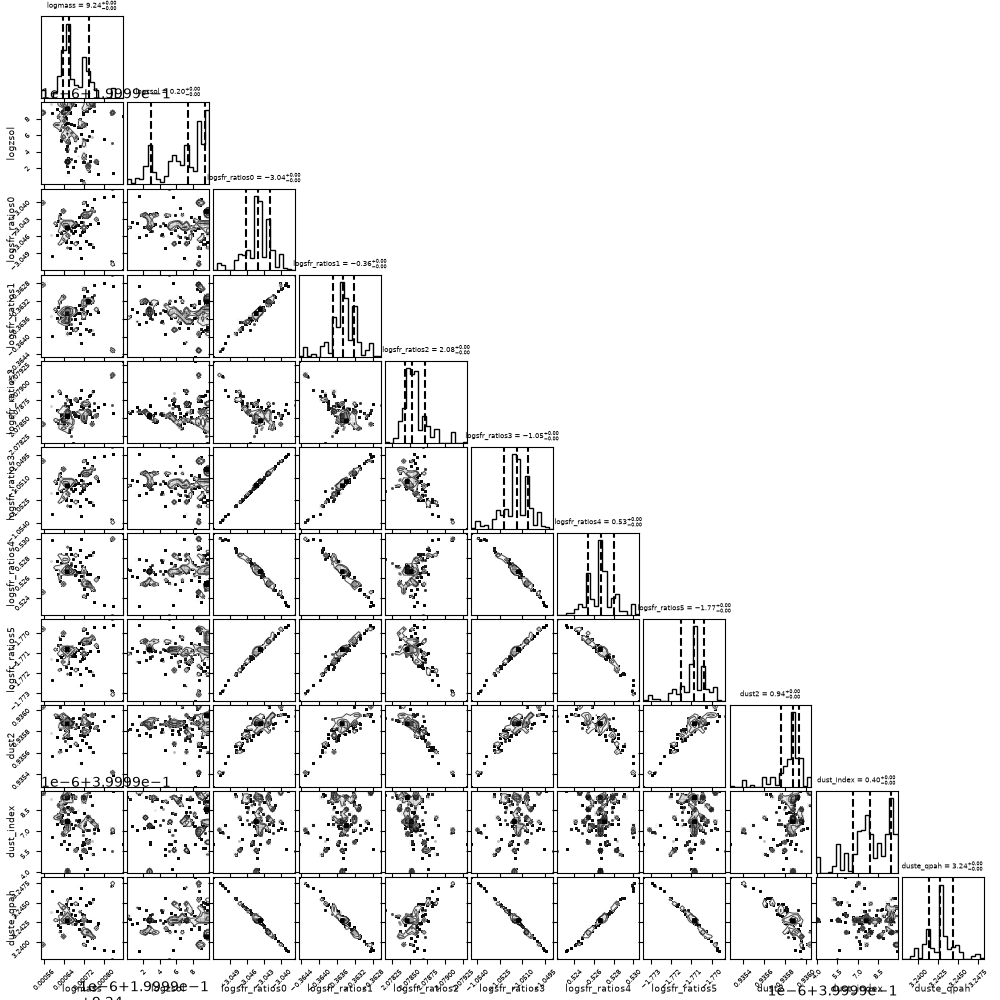

In [110]:
plt.close()
mcmc_libs.plot_corner(results['flat_samples'], ylabels=emcmc_obj.free_param_keys, figsize=(10, 10))

In [162]:
# list(results.keys())

In [218]:
mcmc_libs.display_fits(theta_percentiles=results["theta_percentiles"], keys=emcmc_obj.free_param_keys)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [219]:
all_age_lims, all_sfrs = emcmc_obj.get_continuity_sfh_all_agelims_sfrs()

qs_agelims, qs_agebins_all_sfrs = sps_libs.continuity_sfh_percentiles_steps(
    agelims=all_age_lims,
    sfrs=all_sfrs,
    n_transition=50,
    transition_start_idx=3,
    percentiles=[16,50,84]
)

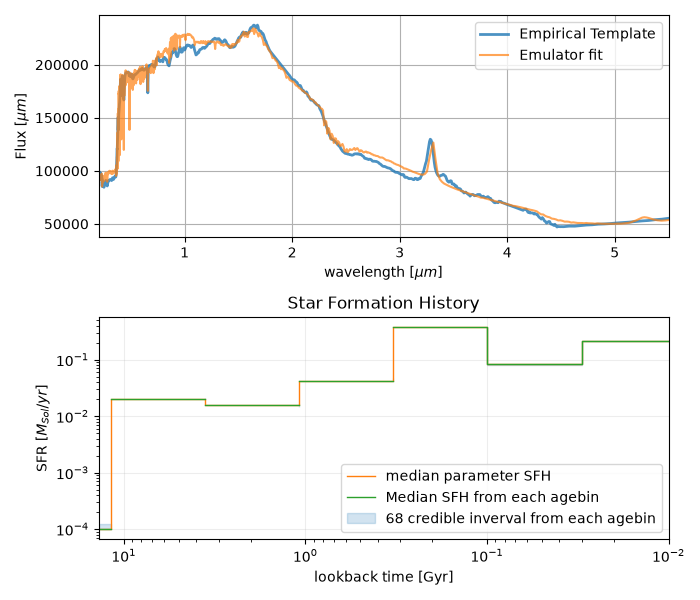

In [220]:
plt.close()
mcmc_libs.plot_sed_sfh(
    figsize=(7,6), 
    lamb_obs=lbs*(1.001),
    spec_obs=flux1,
    lamb_model=results['lbs_med'],
    spec_model=results['flux_med'],
    agelims_model=results['agebins_med'],
    sfrsteps_model=results['sfrs_med'],
    qs_agelims=qs_agelims,
    qs_sfrsteps=qs_agebins_all_sfrs,
    wl_min=0.2,
    wl_max=5.5,
    sed_obs_kwargs={"linewidth": 2, "label": "Empirical Template"},
    sed_model_kwargs={"linewidth": 1.5, "alpha": 0.7, "label": "Emulator fit"}
)